In [2]:
from IPython import display
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as mostrar
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# ------------------------------------------------------------
# 1. Cargar dataset raw
# ------------------------------------------------------------

RAW_PATH = "../Data/NASA_Exoplanet_Archive_Data.csv"
df_raw = pd.read_csv(RAW_PATH)
TARGET = "discoverymethod"

print("Dataset cargado correctamente.")
print(f"Filas originales: {df_raw.shape[0]}")

Dataset cargado correctamente.
Filas originales: 36418


In [3]:
# ------------------------------------------------------------
# 2. Filtrado Inicial (Default Flag y Target)
# ------------------------------------------------------------

df = df_raw[df_raw["default_flag"] == 1].copy()
df = df.dropna(subset=[TARGET]).copy()
df = df.reset_index(drop=True)

print(f"Filas después de filtros básicos: {len(df)}")
print(f"Planetas únicos: {df['pl_name'].nunique()}")

Filas después de filtros básicos: 5757
Planetas únicos: 5757


Distribución del target (Datos Únicos):


discoverymethod
Transit            4304
Radial Velocity    1080
Microlensing        230
Others              143
Name: count, dtype: int64

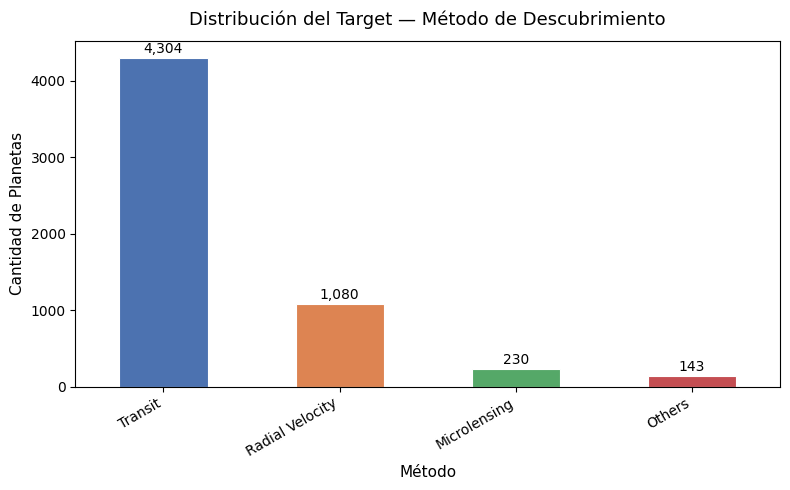

In [4]:
# ------------------------------------------------------------
# 3. Agrupar Categorías del Target
# ------------------------------------------------------------

main_methods = ['Transit', 'Radial Velocity', 'Microlensing']
df[TARGET] = df[TARGET].apply(lambda x: x if x in main_methods else 'Others')

print("Distribución del target (Datos Únicos):")
counts = df[TARGET].value_counts()
mostrar(counts)

plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
counts.plot(kind='bar', color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
plt.title("Distribución del Target — Método de Descubrimiento", fontsize=13, pad=12)
plt.xlabel("Método", fontsize=11)
plt.ylabel("Cantidad de Planetas", fontsize=11)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------
# 4. Mitigación de Data Leakage
# ------------------------------------------------------------

id_cols              = ["pl_name", "hostname"]
metadata_cols        = ["pl_refname", "st_refname", "sy_refname", "rowupdate",
                        "pl_pubdate", "releasedate", "soltype"]
discovery_proc_cols  = ["disc_year", "disc_facility"]
coord_text_cols      = ["rastr", "decstr"]
technical_cols       = ["default_flag", "ttv_flag", "pl_bmassprov", "st_metratio"]
redundant_unit_cols  = ["pl_radj", "pl_bmassj"]
error_lim_cols       = [col for col in df.columns if col.endswith(("err1", "err2", "lim"))]

cols_to_drop = (id_cols + metadata_cols + discovery_proc_cols +
                coord_text_cols + technical_cols + redundant_unit_cols + error_lim_cols)

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")
print(f"Columnas eliminadas: {len(cols_to_drop)}")
print(f"Shape después de mitigación: {df.shape}")

Columnas eliminadas: 19
Shape después de mitigación: (5757, 22)


Columnas con valores nulos:


,nulos,porcentaje_nulos
pl_insol,5026,87.3024
st_spectype,4601,79.9201
pl_eqt,4306,74.7959
pl_orbeccen,3403,59.1106
pl_bmasse,3051,52.9964
pl_orbsmax,2220,38.5618
st_met,1710,29.7030
pl_rade,1415,24.5788
st_logg,984,17.0922
st_mass,751,13.0450


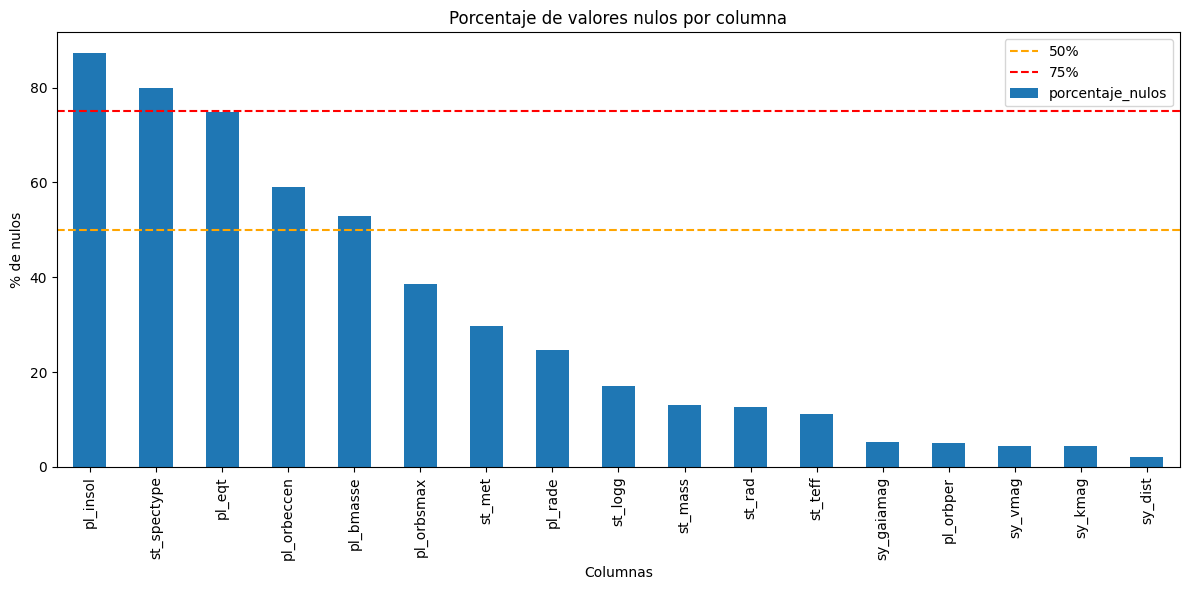

In [7]:
# ------------------------------------------------------------
# 5. Analizar nulos
# ------------------------------------------------------------

null_summary = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje_nulos": df.isnull().mean() * 100
}).sort_values("porcentaje_nulos", ascending=False)

null_summary_nonzero = null_summary[null_summary["nulos"] > 0]

print("Columnas con valores nulos:")
mostrar(null_summary_nonzero)

plt.figure(figsize=(12, 6))
null_summary_nonzero["porcentaje_nulos"].plot(kind="bar")
plt.axhline(50, linestyle="--", label="50%", color="orange")
plt.axhline(75, linestyle="--", label="75%", color="red")
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Columnas")
plt.ylabel("% de nulos")
plt.legend()
plt.tight_layout()
plt.show()

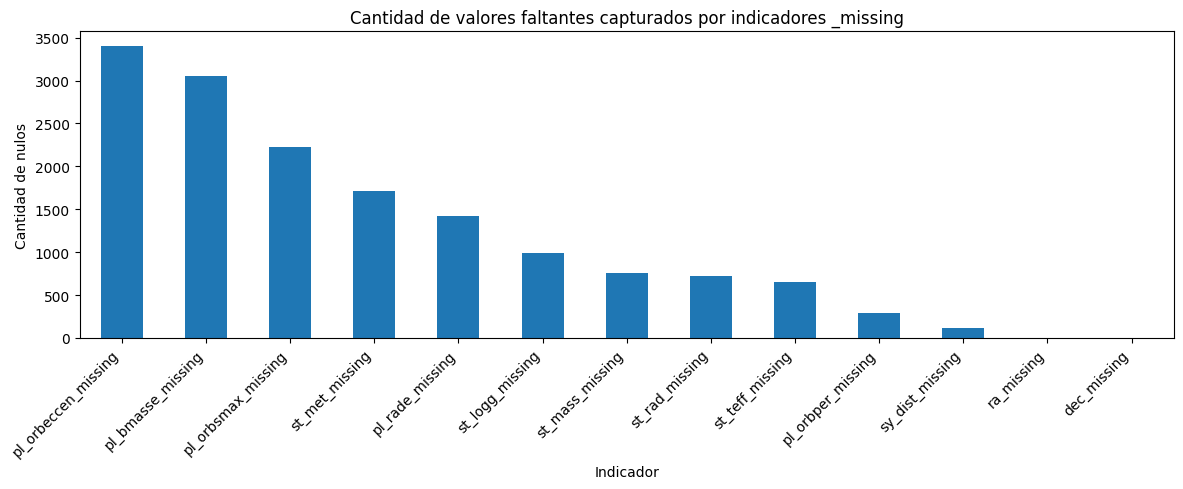

In [8]:
# ------------------------------------------------------------
# 6. Capturar Ausencia Informativa (_missing)
# ------------------------------------------------------------

missing_signal_cols = [
    "pl_bmasse", "pl_rade", "pl_orbper", "pl_orbsmax", "pl_orbeccen",
    "st_teff", "st_rad", "st_mass", "st_met", "st_logg", "sy_dist", "ra", "dec"
]
missing_signal_cols = [col for col in missing_signal_cols if col in df.columns]

for col in missing_signal_cols:
    df[f"{col}_missing"] = df[col].isnull().astype(int)

missing_indicators = [f"{col}_missing" for col in missing_signal_cols]
missing_counts = df[missing_indicators].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing_counts.plot(kind="bar")
plt.title("Cantidad de valores faltantes capturados por indicadores _missing")
plt.xlabel("Indicador")
plt.ylabel("Cantidad de nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
# ------------------------------------------------------------
# 7. Eliminar columnas con nulos excesivos (>75%)
# ------------------------------------------------------------

high_null_cols   = null_summary[null_summary["porcentaje_nulos"] > 75].index.tolist()
protected_cols   = [TARGET] + missing_signal_cols + missing_indicators
cols_to_drop_hn  = [col for col in high_null_cols if col not in protected_cols]

df = df.drop(columns=cols_to_drop_hn, errors="ignore")
print(f"Columnas eliminadas por nulos excesivos: {cols_to_drop_hn}")
print(f"Shape final de datos únicos: {df.shape}")

Columnas eliminadas por nulos excesivos: ['pl_insol', 'st_spectype']
Shape final de datos únicos: (5757, 33)


In [10]:
# ------------------------------------------------------------
# 8. Consistencia Física
# ------------------------------------------------------------

positive_cols = ["pl_rade", "pl_bmasse", "pl_orbper", "pl_orbsmax",
                 "st_teff", "st_rad", "st_mass", "sy_dist"]
positive_cols = [col for col in positive_cols if col in df.columns]

# Excentricidad orbital debe estar en [0, 1]
if "pl_orbeccen" in df.columns:
    df.loc[(df["pl_orbeccen"] < 0) | (df["pl_orbeccen"] > 1), "pl_orbeccen"] = np.nan

invalid_summary = []
for col in positive_cols:
    invalid_count = (df[col] < 0).sum()
    invalid_summary.append({"columna": col, "valores_negativos": invalid_count})
    if invalid_count > 0:
        df.loc[df[col] < 0, col] = np.nan

mostrar(pd.DataFrame(invalid_summary))
print("Consistencia física validada.")

,columna,valores_negativos
0,pl_rade,0
1,pl_bmasse,0
2,pl_orbper,0
3,pl_orbsmax,0
4,st_teff,0
5,st_rad,0
6,st_mass,0
7,sy_dist,0


Consistencia física validada.


In [11]:
# ------------------------------------------------------------
# 9. Transformación Logarítmica (sobre datos crudos ANTES del split)
# NOTA: log1p es una transformación determinista — no genera leakage
# porque no aprende ningún parámetro del dataset.
# ------------------------------------------------------------

skewed_cols = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "sy_dist"]
skewed_cols = [c for c in skewed_cols if c in df.columns]

df_before_processing = df.copy()  # snapshot para visualización

for col in skewed_cols:
    df[col] = np.log1p(df[col])

print(f"Log-transform aplicado a: {skewed_cols}")

Log-transform aplicado a: ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'sy_dist']


Train: 4605 filas | Test: 1152 filas

Distribución train:


discoverymethod
Transit            3443
Radial Velocity     864
Microlensing        184
Others              114
Name: count, dtype: int64


Distribución test:


discoverymethod
Transit            861
Radial Velocity    216
Microlensing        46
Others              29
Name: count, dtype: int64

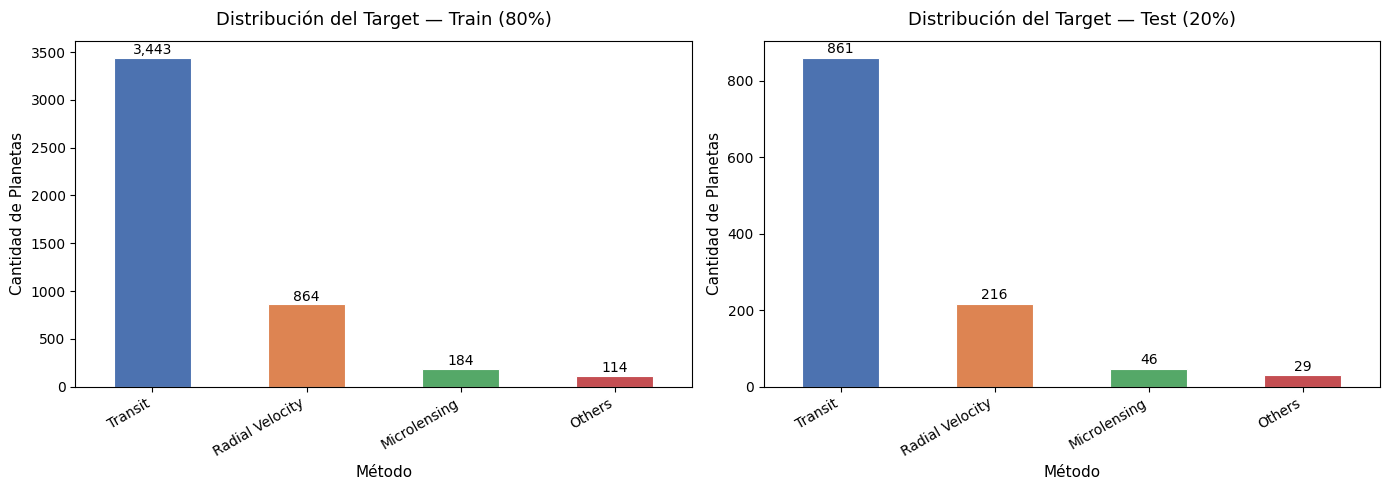

In [12]:
# ============================================================
# 10. Train / Test Split  ← DEBE HACERSE ANTES de KNN y SMOTE
# ============================================================
# IMPORTANTE: KNNImputer y SMOTE se fitean SOLO sobre train.
# Si se fitean sobre el dataset completo, datos de test "filtran"
# información al modelo, inflando artificialmente las métricas.
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("\nDistribución train:")
mostrar(y_train.value_counts())
print("\nDistribución test:")
mostrar(y_test.value_counts())

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, titulo in zip(
    axes,
    [y_train.value_counts(), y_test.value_counts()],
    ["Train (80%)", "Test (20%)"]
):
    counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
    ax.set_title(f"Distribución del Target — {titulo}", fontsize=13, pad=12)
    ax.set_xlabel("Método", fontsize=11)
    ax.set_ylabel("Cantidad de Planetas", fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xticklabels(counts.index, ha='right')
    for i, v in enumerate(counts):
        ax.text(i, v + 5, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
# ------------------------------------------------------------
# 11. Winsorización — fit en train, transform en ambos
# ------------------------------------------------------------
# Recorta valores extremos al percentil 1 y 99 de cada columna.
# Esto elimina las concentraciones extremas que SMOTE luego
# amplifica al generar muestras sintéticas en esas zonas.
# Se fitea SOLO en train para evitar leakage.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
winsorize_cols = [col for col in numeric_cols if not col.endswith("_missing")]

# Aprender límites solo en train
lower_bounds = X_train[winsorize_cols].quantile(0.01)
upper_bounds = X_train[winsorize_cols].quantile(0.99)

# Aplicar a train y test
X_train[winsorize_cols] = X_train[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)
X_test[winsorize_cols] = X_test[winsorize_cols].clip(
    lower=lower_bounds, upper=upper_bounds, axis=1
)

print(f"Winsorización aplicada a {len(winsorize_cols)} columnas (p1-p99).")
print("Filas eliminadas: 0 — solo se recortan los valores extremos.")

Winsorización aplicada a 19 columnas (p1-p99).
Filas eliminadas: 0 — solo se recortan los valores extremos.


In [14]:
# ------------------------------------------------------------
# 12. Imputación KNN — fit en train, transform en ambos
# ------------------------------------------------------------
# Las columnas _missing (0/1) no tienen NaNs: se excluyen del
# imputer para no distorsionar las distancias KNN.
# ------------------------------------------------------------

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_no_missing = [col for col in numeric_cols if not col.endswith("_missing")]

imputer = KNNImputer(n_neighbors=5)
X_train[numeric_no_missing] = imputer.fit_transform(X_train[numeric_no_missing])  # fit + transform
X_test[numeric_no_missing]  = imputer.transform(X_test[numeric_no_missing])        # solo transform

# Categóricas: imputar con 'Unknown'
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown")
    X_test[col]  = X_test[col].fillna("Unknown")

print("Imputación KNN completada (sin leakage).")

Imputación KNN completada (sin leakage).


Distribución TRAIN balanceado con SMOTEENN (11591 filas):


discoverymethod
Microlensing       3388
Others             3067
Radial Velocity    2798
Transit            2338
Name: count, dtype: int64

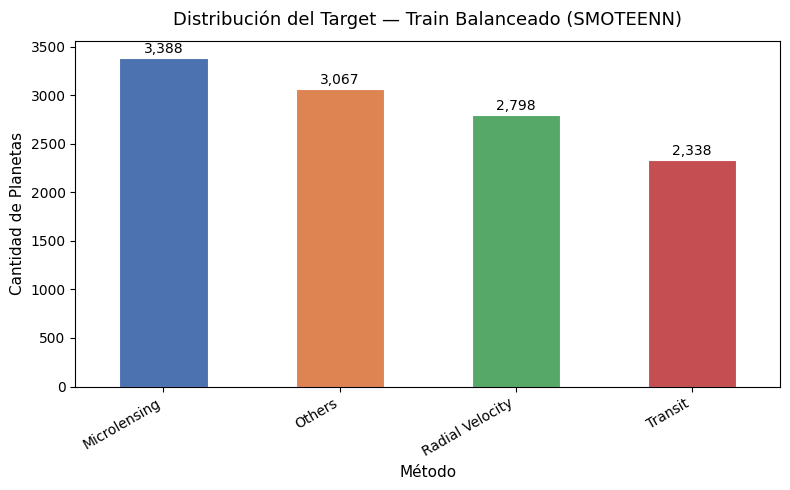


Distribución TEST sin modificar (1152 filas):


discoverymethod
Transit            861
Radial Velocity    216
Microlensing        46
Others              29
Name: count, dtype: int64

In [15]:
# ------------------------------------------------------------
# 13. Balanceo con SMOTEENN — solo sobre TRAIN
# ------------------------------------------------------------
# SMOTEENN = SMOTE + Edited Nearest Neighbours (ENN)
#   · SMOTE genera muestras sintéticas interpolando entre vecinos.
#   · ENN luego ELIMINA las muestras (reales y sintéticas) que
#     son clasificadas incorrectamente por sus vecinos más cercanos.
# Resultado: distribución más suave y limpia que SMOTE solo,
# porque ENN borra los sintéticos que cayeron en zonas densas
# (justo donde se formaban los picos).
# El test set NUNCA se toca — refleja la distribución real.
# ------------------------------------------------------------

# Encodear columnas categóricas para SMOTEENN (requiere valores numéricos)
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str).apply(
        lambda v: v if v in le.classes_ else le.classes_[0]
    ))
    encoders[col] = le

# Encodear target
le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train)
y_test_enc  = le_target.transform(y_test)

# Aplicar SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_train_bal, y_train_bal_enc = smoteenn.fit_resample(X_train, y_train_enc)

# Reconstruir DataFrames con nombres de columnas
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)
y_train_bal = pd.Series(le_target.inverse_transform(y_train_bal_enc), name=TARGET)

print(f"Distribución TRAIN balanceado con SMOTEENN ({len(X_train_bal)} filas):")
counts_bal = y_train_bal.value_counts()
mostrar(counts_bal)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
plt.figure(figsize=(8, 5))
counts_bal.plot(kind='bar', color=colors[:len(counts_bal)], edgecolor='white', linewidth=0.8)
plt.title("Distribución del Target — Train Balanceado (SMOTEENN)", fontsize=13, pad=12)
plt.xlabel("Método", fontsize=11)
plt.ylabel("Cantidad de Planetas", fontsize=11)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts_bal):
    plt.text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nDistribución TEST sin modificar ({len(X_test)} filas):")
mostrar(y_test.value_counts())

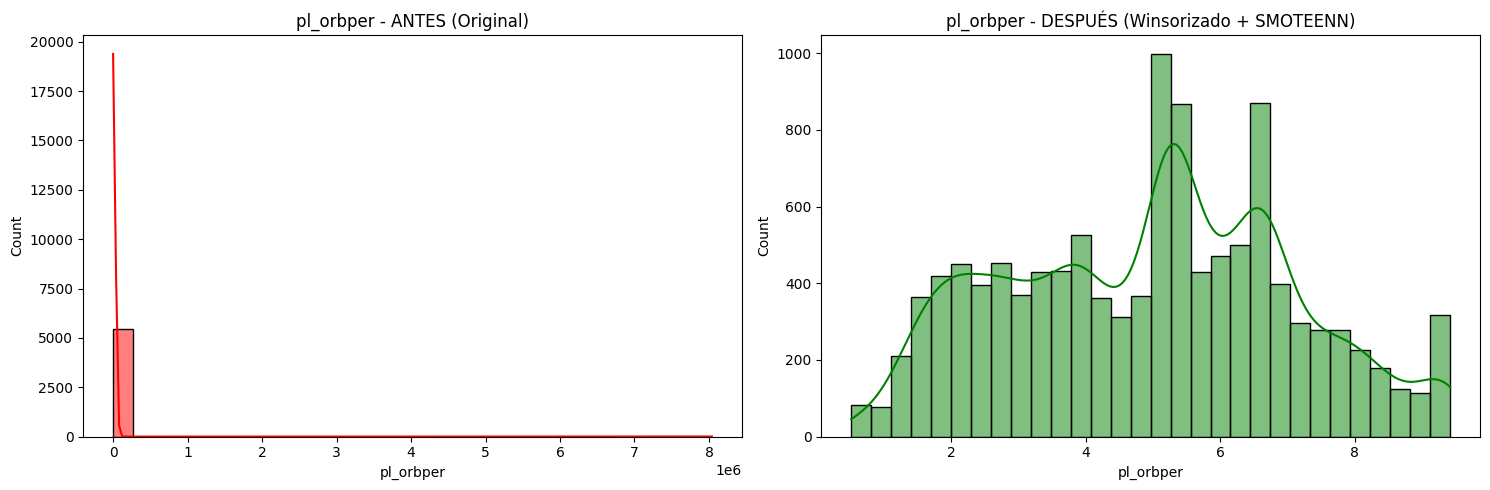

--- Tabla de frecuencias: pl_orbper ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.5096,1.4002,369
1,1.4002,2.2907,1234
2,2.2907,3.1812,1218
3,3.1812,4.0718,1387
4,4.0718,4.9623,1038
5,4.9623,5.8529,2294
6,5.8529,6.7434,1840
7,6.7434,7.6340,971
8,7.6340,8.5245,684
9,8.5245,9.4150,556


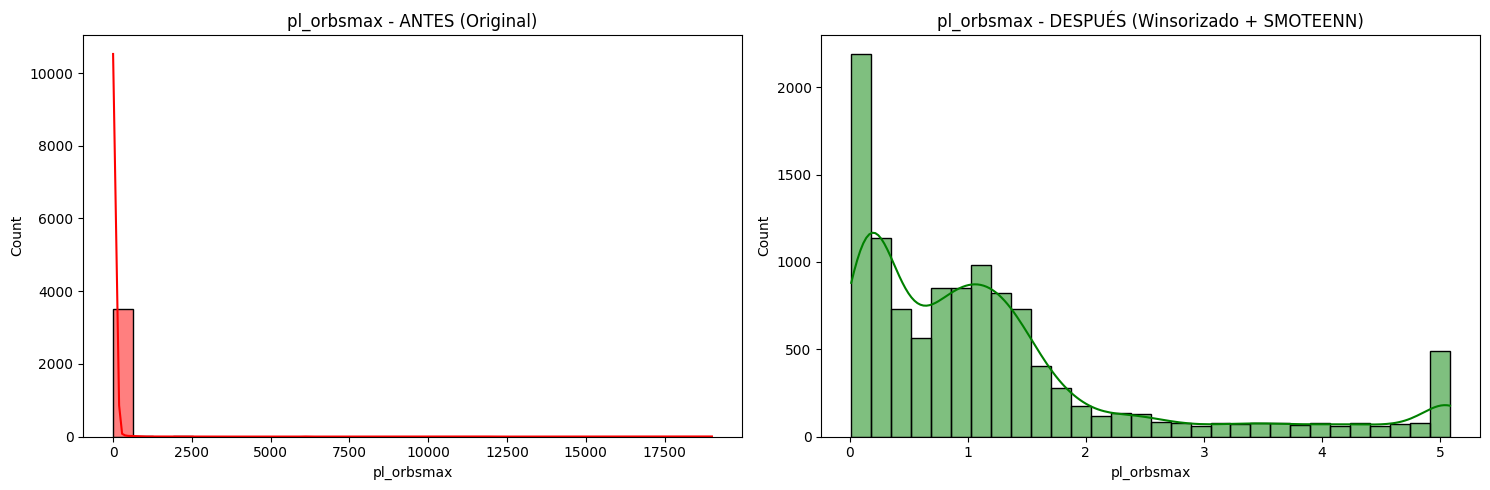

--- Tabla de frecuencias: pl_orbsmax ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.0140,0.5210,4055
1,0.5210,1.0281,2262
2,1.0281,1.5351,2530
3,1.5351,2.0422,857
4,2.0422,2.5492,384
5,2.5492,3.0562,220
6,3.0562,3.5633,230
7,3.5633,4.0703,220
8,4.0703,4.5774,197
9,4.5774,5.0844,636


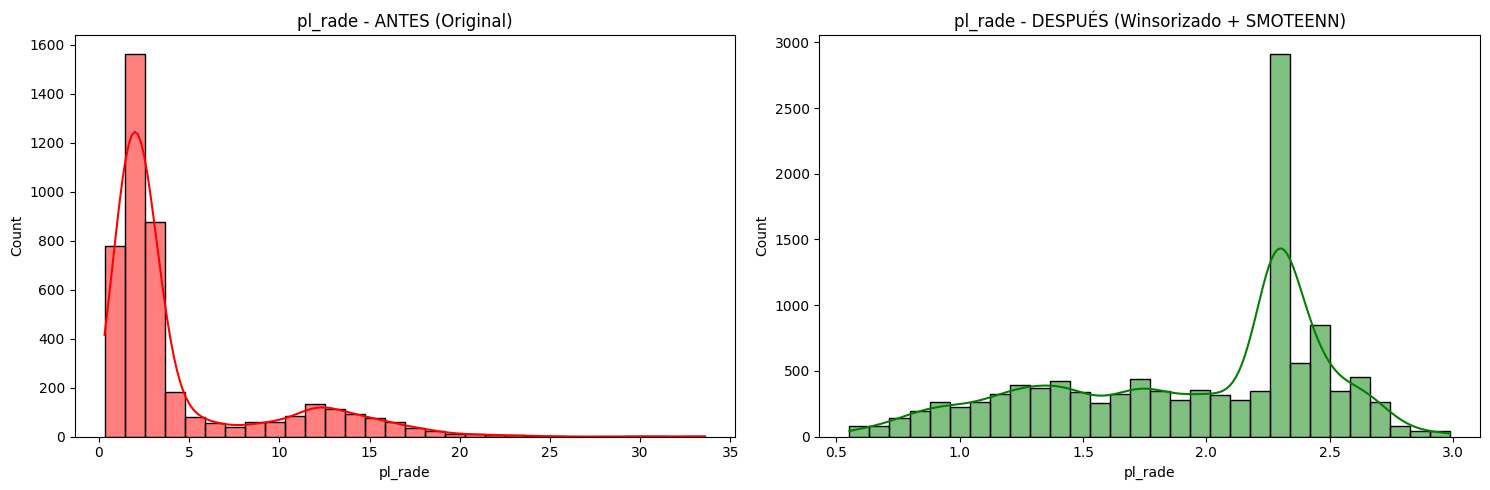

--- Tabla de frecuencias: pl_rade ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.5539,0.7972,303
1,0.7972,1.0405,679
2,1.0405,1.2838,981
3,1.2838,1.5271,1135
4,1.5271,1.7704,1014
5,1.7704,2.0137,982
6,2.0137,2.2570,947
7,2.2570,2.5003,4321
8,2.5003,2.7436,1065
9,2.7436,2.9868,164


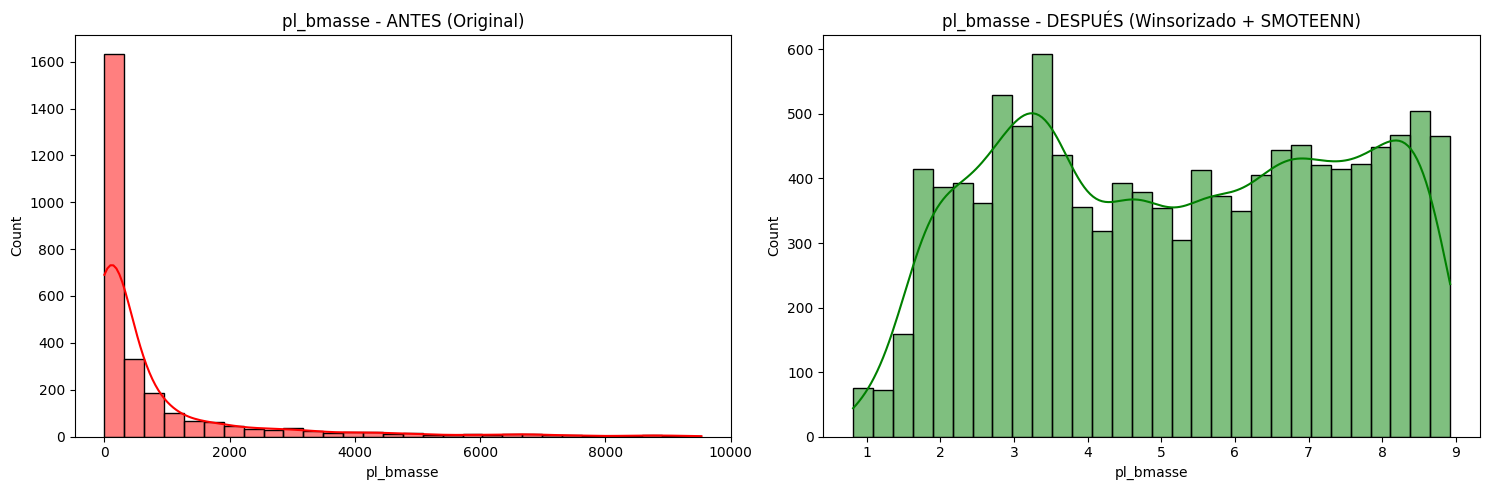

--- Tabla de frecuencias: pl_bmasse ---


,Rango_Inicio,Rango_Fin,Cantidad
0,0.8151,1.6259,307
1,1.6259,2.4367,1194
2,2.4367,3.2475,1373
3,3.2475,4.0583,1385
4,4.0583,4.8691,1091
5,4.8691,5.6799,1071
6,5.6799,6.4907,1128
7,6.4907,7.3015,1317
8,7.3015,8.1123,1287
9,8.1123,8.9231,1438


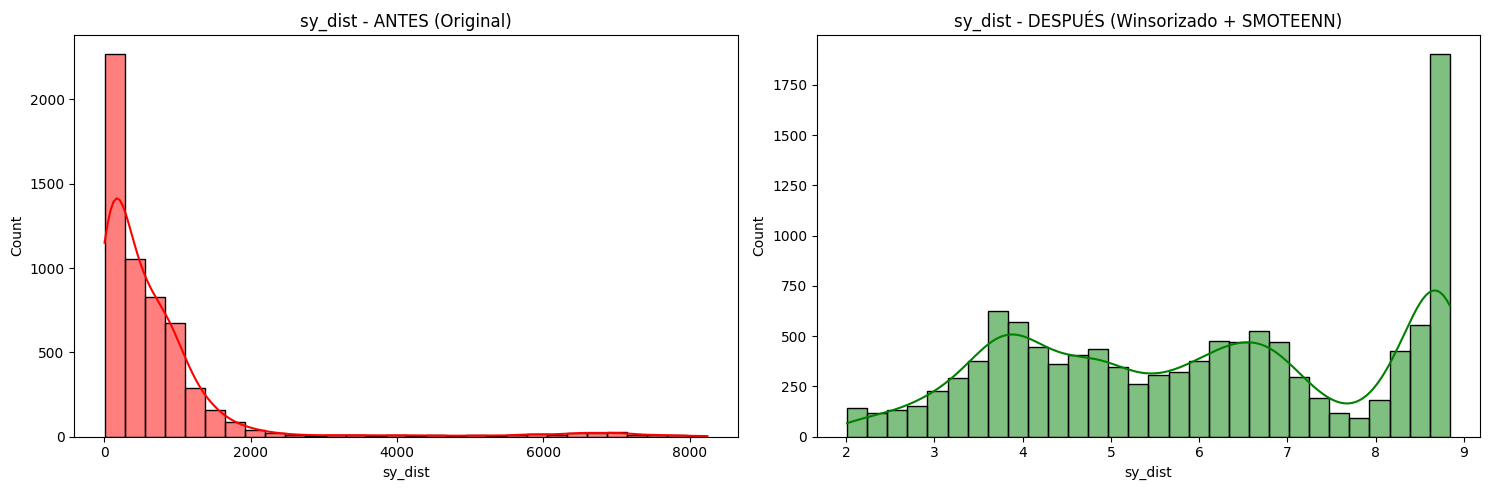

--- Tabla de frecuencias: sy_dist ---


,Rango_Inicio,Rango_Fin,Cantidad
0,2.0124,2.6951,386
1,2.6951,3.3778,672
2,3.3778,4.0604,1574
3,4.0604,4.7431,1212
4,4.7431,5.4258,1041
5,5.4258,6.1085,1004
6,6.1085,6.7912,1470
7,6.7912,7.4738,958
8,7.4738,8.1565,389
9,8.1565,8.8392,2885



ETL finalizado correctamente.
Objetos disponibles para modelado:
  X_train_bal, y_train_bal  → entrenamiento (Winsorizado + SMOTEENN)
  X_test,      y_test       → evaluación   (distribución real, sin modificar)


In [16]:
# ------------------------------------------------------------
# 14. Visualización Comparativa
# ANTES: dataset crudo (con outliers y skew)
# DESPUÉS: train post-Winsorización + SMOTEENN
# ------------------------------------------------------------

cols_to_plot = [c for c in ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "sy_dist"] if c in X_train_bal.columns]

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # ANTES (datos originales, escala raw)
    sns.histplot(df_before_processing[col].dropna(), kde=True, ax=axes[0], color="red", bins=30)
    axes[0].set_title(f"{col} - ANTES (Original)")

    # DESPUÉS (train con log1p + SMOTEENN)
    sns.histplot(X_train_bal[col], kde=True, ax=axes[1], color="green", bins=30)
    axes[1].set_title(f"{col} - DESPUÉS (Winsorizado + SMOTEENN)")

    plt.tight_layout()
    plt.show()

    # Tabla de Frecuencias
    counts, bin_edges = np.histogram(X_train_bal[col], bins=10)
    tabla = pd.DataFrame({
        "Rango_Inicio": bin_edges[:-1].round(4),
        "Rango_Fin"   : bin_edges[1:].round(4),
        "Cantidad"    : counts
    })
    print(f"--- Tabla de frecuencias: {col} ---")
    mostrar(tabla)

print("\nETL finalizado correctamente.")
print("Objetos disponibles para modelado:")
print("  X_train_bal, y_train_bal  → entrenamiento (Winsorizado + SMOTEENN)")
print("  X_test,      y_test       → evaluación   (distribución real, sin modificar)")